In [13]:
import os
import sys
import random
import dotenv
import pandas as pd
import torch
from diffusers import AutoPipelineForText2Image
import matplotlib.pyplot as plt

sys.path.append('..')
dotenv.load_dotenv()
os.environ['WANDB_DISABLED'] = "true"
assert len(os.getenv('HF_TOKEN'))>0

from vision_unlearning.unlearner import UnlearnerLoraDirect
from vision_unlearning.utils.logger import get_logger, setup_loggers
from vision_unlearning.datasets import UnlearnDatasetImagenette, UnlearnDatasetSplitMode
from vision_unlearning.utils.gradient_weighting import GradientWeightingMethodMunba
from vision_unlearning.utils.prompts import prompts

In [2]:
num_train_epochs = 5
model_base_name = "CompVis/stable-diffusion-v1-4"
model_lora_path = f"assets/models/munba_airplane_{num_train_epochs:03d}"
hub_model_id = "LeonardoBenitez/demo-vision-unlearning-munba"
dataset_base_path = 'assets/datasets/imagenette_splits'

c = "n03888257"  # Parachute class
max_eval_prompts = 100

validation_prompt = f'An image of a parachute'
example_prompts_forget = [
    f'An image of a parachute',
    f'Photograph of a parachute; high definition',
]
example_prompts_retain = [
    f'An image of an airplane',
    f'Photograph of an air baloon; high definition',
]

### No need to change anything from now on... ###
logger = get_logger('main')
setup_loggers(modules_info=['vision_unlearning.'])
device = 'cuda' if torch.cuda.is_available() else 'cpu'
os.environ['TOKENIZERS_PARALLELISM'] = 'true'  # To stop warnings "The current process just got forked"

c_human = UnlearnDatasetImagenette.class_mapping[c]
dataset_forget_name = f"{dataset_base_path}/{c}/train_forget"
dataset_retain_name = f"{dataset_base_path}/{c}/train_retain"

# Assemble the evaluation prompts
final_eval_prompts_forget = prompts[f'imagenette_{c_human}']['forget'][:max_eval_prompts]
final_eval_prompts_retain = []
for category in prompts:
    if category.startswith('imagenette') and not category.endswith(c_human):
        final_eval_prompts_retain += prompts[category]['forget']
random.shuffle(final_eval_prompts_retain)
final_eval_prompts_retain = final_eval_prompts_retain[:len(final_eval_prompts_forget)]

# Original model
As you can see, it can generate the undesired concept

In [5]:
pipeline = AutoPipelineForText2Image.from_pretrained(model_base_name, torch_dtype=torch.float16, safety_checker=None).to(device)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/50 [00:00<?, ?it/s]

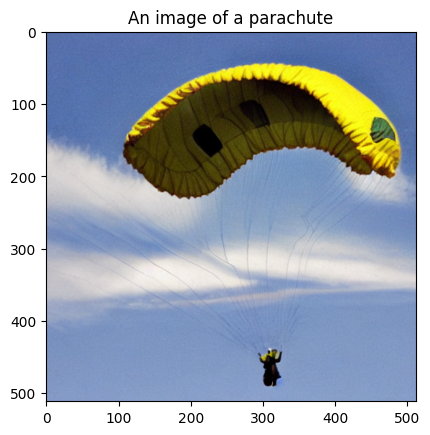

  0%|          | 0/50 [00:00<?, ?it/s]

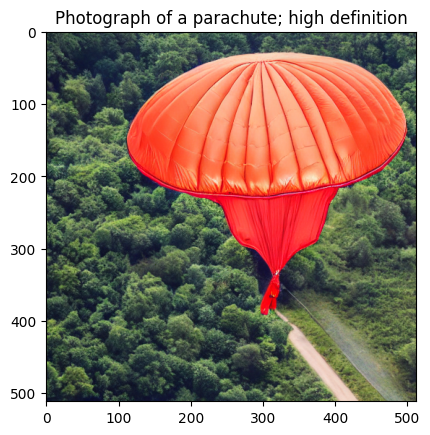

  0%|          | 0/50 [00:00<?, ?it/s]

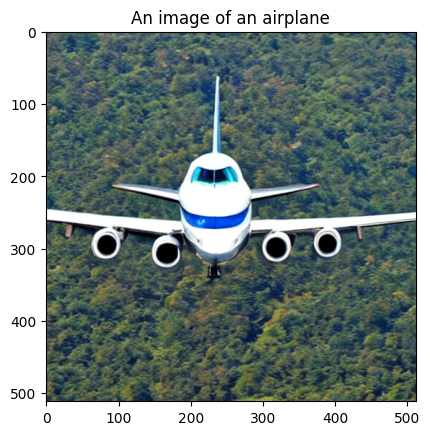

  0%|          | 0/50 [00:00<?, ?it/s]

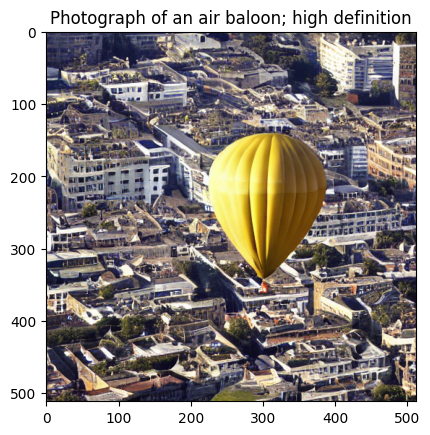

In [8]:
for prompt in example_prompts_forget + example_prompts_retain:
    image = pipeline(prompt).images[0]
    plt.imshow(image)
    plt.title(prompt)
    plt.show()

In [9]:
del pipeline
gc.collect()
torch.cuda.empty_cache()

NameError: name 'gc' is not defined

# Prepare dataset for unlearning
images of the concept to be forgotten + some random images of concepts to be retained

In [5]:
#if os.path.exists(dataset_base_path):
#    shutil.rmtree(dataset_base_path)
if not os.path.exists('assets/imagenette_splits'):
    dataset = UnlearnDatasetImagenette(
        split_mode=UnlearnDatasetSplitMode.Class,
        split_kwargs={"forget": [c]},
        download_path=dataset_base_path,
    )
    dataset.save(f"{dataset_base_path}/{c}", format='jpg')
else:
    print('Splits already exist, not downloading again')

Download complete.
Extracting dataset...
Extraction complete.


# Unlearning
Performing the actual model update

In [10]:
!nvidia-smi

Sun Nov  9 20:31:54 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.05              Driver Version: 560.35.05      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100-PCIE-16GB           Off |   00000000:18:00.0 Off |                    0 |
| N/A   49C    P0             46W /  250W |    3550MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [15]:
free_memory, total_memory = torch.cuda.mem_get_info()  # in GB
logger.info(f"Free Memory: {free_memory / 1e9:.2f} GB")
logger.info(f"Total Memory: {total_memory / 1e9:.2f} GB")

hyperparameters = {
    "dataloader_num_workers": 2,
    "resolution": 512,
    "num_validation_images": 1,

    "mixed_precision": "no",
    "learning_rate": 1e-4,
    "max_grad_norm": 1.0,
    "lr_scheduler_type": "lr_scheduler",
    "lr_warmup_steps": 0,
    "num_train_epochs": num_train_epochs,
    "validation_epochs": 1,
    "checkpointing_steps": 10000,
    "lr_scheduler_type": "cosine",
    "logging_steps": 20,
    "save_strategy": "epoch",
    "save_total_limit": 2,
    "random_flip": True,

    "lora_r": 4,
    "target_modules": ["to_k", "to_q", "to_v", "to_out.0"],
    "lora_alpha": 4,
    "lora_dropout": 0.1,

    "seed": 42,
}

if free_memory > 20e9:
    hyperparameters.update({
        "per_device_train_batch_size": 8,
        "gradient_accumulation_steps": 1,
    })
elif free_memory > 14e9:
    hyperparameters.update({
        "per_device_train_batch_size": 4,
        "gradient_accumulation_steps": 2,
    })
else:
    logger.error('Too little GPU, diverting power from life support...')
    hyperparameters.update({
        "per_device_train_batch_size": 1,
        "gradient_accumulation_steps": 8,
    })

logger.info(hyperparameters)

[2025-11-09 20:35:01 +0100] vision_unlearning.main INFO     Free Memory: 13.21 GB
[2025-11-09 20:35:01 +0100] vision_unlearning.main INFO     Total Memory: 16.93 GB
[2025-11-09 20:35:01 +0100] vision_unlearning.main ERROR    Too little GPU, diverting power from life support...
[2025-11-09 20:35:01 +0100] vision_unlearning.main INFO     {'dataloader_num_workers': 2, 'resolution': 512, 'num_validation_images': 1, 'mixed_precision': 'no', 'learning_rate': 0.0001, 'max_grad_norm': 1.0, 'lr_scheduler_type': 'cosine', 'lr_warmup_steps': 0, 'num_train_epochs': 5, 'validation_epochs': 1, 'checkpointing_steps': 10000, 'logging_steps': 20, 'save_strategy': 'epoch', 'save_total_limit': 2, 'random_flip': True, 'lora_r': 4, 'target_modules': ['to_k', 'to_q', 'to_v', 'to_out.0'], 'lora_alpha': 4, 'lora_dropout': 0.1, 'seed': 42, 'per_device_train_batch_size': 1, 'gradient_accumulation_steps': 8}


In [16]:
unlearner = UnlearnerLoraDirect(
    model_name_or_path=model_base_name,
    dataset_forget_name=dataset_forget_name,
    dataset_retain_name=dataset_retain_name,
    output_dir=model_lora_path,
    validation_prompt=validation_prompt,
    gradient_weighting_method = GradientWeightingMethodMunba(),
    final_eval_prompts_forget = final_eval_prompts_forget,
    final_eval_prompts_retain = final_eval_prompts_retain,
    hub_model_id = hub_model_id,
)

In [17]:
eval_results = unlearner.train()
df = pd.DataFrame([{'Name': r.metric_name, 'Value': r.metric_value} for r in eval_results])
df

[2025-11-09 20:35:22 +0100] vision_unlearning.unlearner WARNING  Self distillation was never tested with more advanced gradient weighting methods


Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


[2025-11-09 20:35:26 +0100] vision_unlearning.unlearner INFO     Number of lora layers: 256


Resolving data files:   0%|          | 0/865 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

...

[2025-11-09 20:35:37 +0100] vision_unlearning.unlearner INFO     Retain dataset: DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 7661
    })
})
Forget dataset: DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 864
    })
})
[2025-11-09 20:35:37 +0100] vision_unlearning.unlearner INFO     Dataset config - Image column: image, caption column: text


Parameter 'transform'=<function UnlearnerLoraDirect._prepare_dataloaders.<locals>.<lambda> at 0x7f3a437b1090> of the transform datasets.arrow_dataset.Dataset.set_format couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only shown once. Subsequent hashing failures won't be shown.


[2025-11-09 20:35:37 +0100] vision_unlearning.unlearner INFO     Number of training examples = 864 + 7661
[2025-11-09 20:35:37 +0100] vision_unlearning.unlearner INFO     ***** Running training *****
[2025-11-09 20:35:37 +0100] vision_unlearning.unlearner INFO       Num Epochs = 1
[2025-11-09 20:35:37 +0100] vision_unlearning.unlearner INFO       Instantaneous batch size per device = 1
[2025-11-09 20:35:37 +0100] vision_unlearning.unlearner INFO       Total train batch size (w. parallel, distributed & accumulation) = 128
[2025-11-09 20:35:37 +0100] vision_unlearning.unlearner INFO       Gradient Accumulation steps = 128
[2025-11-09 20:35:37 +0100] vision_unlearning.unlearner INFO       Total optimization steps = 7


Steps:   0%|          | 0/7 [00:00<?, ?it/s]

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f3c39801330>>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 

KeyboardInterrupt



# Check unlearned model
as you can see, it does NOT generate the undesired concept anymore

In [ ]:
pipeline = AutoPipelineForText2Image.from_pretrained(model_base_name, torch_dtype=torch.float16, safety_checker=None).to(device)
pipeline.load_lora_weights(model_lora_path, weight_name='pytorch_lora_weights.safetensors')

In [ ]:
for prompt in example_prompts_forget + example_prompts_retain:
    image = pipeline(prompt).images[0]
    plt.imshow(image)
    plt.title(prompt)
    plt.show()